### Importing Libraries

In [35]:
from keras.models import load_model
from keras.preprocessing import image
from keras.applications.vgg16 import preprocess_input
from keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

### VGG 16

In [36]:
model_1 = load_model('model_vgg16.keras')

### Performance Metrics

#### Loading the test set

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('Dataset_2/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

y_test = test_set.classes

Found 624 images belonging to 2 classes.


In [27]:
# making predictions
predictions = model_1.predict(test_set)


20/20 [==============================] - 211s 11s/step


In [32]:
# Convert the predictions and true labels to class indices (0 for "normal" and 1 for "pneumonia")
predicted_labels = np.argmax(predictions, axis=1)
true_labels = y_test

# Calculating the confusion matrix
confusion = confusion_matrix(true_labels, predicted_labels)

# Defining class names
class_names = ["Normal", "Pneumonia"]


### classification report

In [33]:
from sklearn.metrics import classification_report


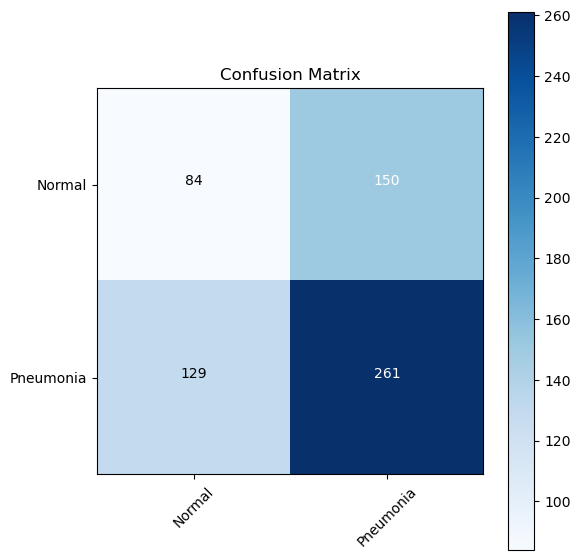

In [34]:
# Function to plot the confusion matrix
def plot_confusion_matrix(confusion_matrix, class_names):
    plt.figure(figsize=(6, 6))
    plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.tight_layout()
    
# Annotate the cells with their respective values
    thresh = confusion_matrix.max() / 2.
    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            plt.text(j, i, format(confusion_matrix[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if confusion_matrix[i, j] > thresh else "black")
    
# Plotting the confusion matrix
plot_confusion_matrix(confusion, class_names)
plt.show()

In [31]:
# Generate a classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.39      0.36      0.38       234
   Pneumonia       0.64      0.67      0.65       390

    accuracy                           0.55       624
   macro avg       0.51      0.51      0.51       624
weighted avg       0.54      0.55      0.55       624



### single prediction

In [39]:

test_image  = image.load_img('Dataset_2/val/NORMAL/IM-0413-0001.jpeg', target_size = (224,224))
#test_image  = image.load_img('Dataset_2/val/PNEUMONIA/person100_bacteria_475.jpeg', target_size = (224,224))
test_image  = image.img_to_array(test_image )
test_image = np.expand_dims(test_image, axis = 0)

result = model_1.predict(test_image )

print(result )
#training_set.class_indices
if result [0][0]< result [0][1]:
    prediction = 'pneumonia'
else:
    prediction = 'normal'
    
print(prediction)

1/1 [==============================] - 0s 369ms/step
[[1.0000000e+00 9.6173265e-35]]
normal


## ResNet 50

In [40]:
model_2 = load_model('model_resnet_50.keras')

In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_datagen = ImageDataGenerator(rescale = 1./255)
test_set = test_datagen.flow_from_directory('Dataset_2/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

y_test = test_set.classes

Found 624 images belonging to 2 classes.


In [22]:
# making predictions
predictions = model_2.predict(test_set)


20/20 [==============================] - 73s 4s/step


In [23]:
# Converting the predictions and true labels to class indices (0 for "normal" and 1 for "pneumonia")
predicted_labels = np.argmax(predictions, axis=1)
true_labels = y_test

# Calculating the confusion matrix
confusion = confusion_matrix(true_labels, predicted_labels)

# Defining class names
class_names = ["Normal", "Pneumonia"]


### Classification report

In [24]:
from sklearn.metrics import classification_report


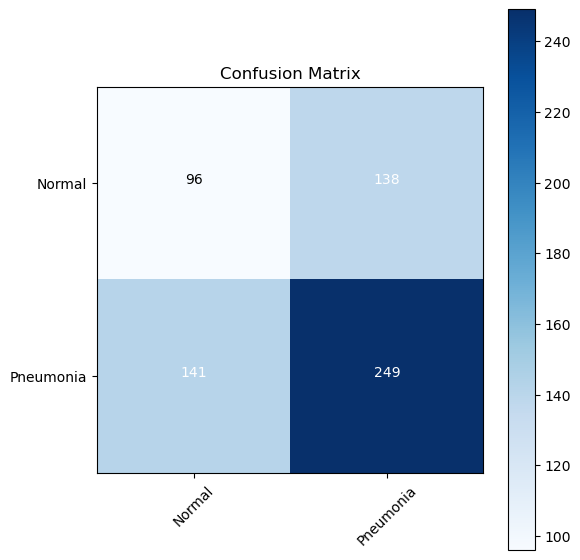

In [25]:
# Function to plot the confusion matrix
def plot_confusion_matrix(confusion_matrix, class_names):
    plt.figure(figsize=(6, 6))
    plt.imshow(confusion_matrix, interpolation='nearest', cmap=plt.get_cmap('Blues'))
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    plt.tight_layout()
    
# Annotate the cells with their respective values
    thresh = confusion_matrix.max() / 2.
    for i in range(confusion_matrix.shape[0]):
        for j in range(confusion_matrix.shape[1]):
            plt.text(j, i, format(confusion_matrix[i, j], 'd'),
                     horizontalalignment="center",
                     color="white" if confusion_matrix[i, j] > thresh else "black")

# Plotting the confusion matrix
plot_confusion_matrix(confusion, class_names)
plt.show()

In [17]:
# Generate a classification report
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)

              precision    recall  f1-score   support

      Normal       0.38      0.39      0.39       234
   Pneumonia       0.63      0.63      0.63       390

    accuracy                           0.54       624
   macro avg       0.51      0.51      0.51       624
weighted avg       0.54      0.54      0.54       624



In [42]:
test_image  = image.load_img('Dataset_2/val/NORMAL/IM-0414-0001.jpeg', target_size = (224,224))
#test_image  = image.load_img('Dataset_2/val/PNEUMONIA/person99_bacteria_474.jpeg', target_size = (224,224))
test_image  = image.img_to_array(test_image)
test_image  = np.expand_dims(test_image , axis = 0)

result  = model_2.predict(test_image )

print(result )

if result[0][0]< result[0][1]:
    prediction = 'pneumonia'
else:
    prediction = 'normal'
    
print(prediction)

1/1 [==============================] - 0s 338ms/step
[[5.0802714e-06 9.9999487e-01]]
pneumonia
